# Baseline Response Model Training

This notebook visually walks through baseline response model training.

The response model predicts:

```text
P(conversion | features)
```

This is not an uplift model yet. It is a supervised classification baseline used before the T-Learner uplift model.


In [1]:
import sys
from pathlib import Path

import pandas as pd

# Khai báo đường dẫn gốc
ROOT_DIR = Path("..")

# Thêm ROOT_DIR vào sys.path để cấu trúc 'from src...' hoạt động
sys.path.insert(0, str(ROOT_DIR))
import pandas as pd

from src.data.constants import PROCESSED_DIR
from src.data.validate_schema import resolve_target_column
from src.models.train_response_model import train_response_models
from src.visualization.model_training import (
    feature_summary,
    plot_feature_histograms,
    plot_treatment_outcome_summary,
    summarize_dataset,
    treatment_outcome_summary,
)


c:\Users\chauh\miniconda3\envs\retention-uplift-mlops\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load processed datasets

In [4]:
train_df = pd.read_parquet(".." / PROCESSED_DIR / "train.parquet")
valid_df = pd.read_parquet(".." / PROCESSED_DIR / "valid.parquet")

target_col = resolve_target_column(train_df)

train_df.shape, valid_df.shape, target_col


((700000, 13), (150000, 13), 'conversion')

## Dataset summary

In [5]:
summarize_dataset(train_df, target_col=target_col)

,n_rows,n_features,target_col,target_rate,treatment_rate,n_treatment,n_control
0,700000,11,conversion,0.002881,0.850411,595288,104712


## Treatment/control outcome summary

In [6]:
group_summary = treatment_outcome_summary(train_df, target_col=target_col)
group_summary


,treatment,n_users,outcome_rate
0,0,104712,0.001824
1,1,595288,0.003067


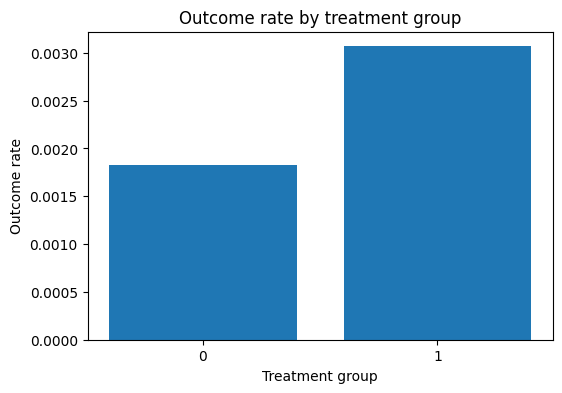

In [7]:
plot_treatment_outcome_summary(group_summary)

## Feature summary

In [8]:
feature_summary(train_df)

,feature,count,mean,std,min,25%,50%,75%,max
0,f0,700000.0,19.624676,5.378604,12.616365,12.616365,21.925617,24.452326,26.745253
1,f1,700000.0,10.069752,0.104078,10.059654,10.059654,10.059654,10.059654,15.640628
2,f2,700000.0,8.446750,0.299526,8.214383,8.214383,8.214383,8.724874,9.051958
3,f3,700000.0,4.179621,1.335256,-6.134915,4.679882,4.679882,4.679882,4.679882
4,f4,700000.0,10.339116,0.343943,10.280525,10.280525,10.280525,10.280525,19.328831
5,f5,700000.0,4.029443,0.428963,-8.912209,4.115453,4.115453,4.115453,4.115453
6,f6,700000.0,-4.154345,4.577437,-29.467640,-6.699321,-2.411115,0.294443,0.294443
7,f7,700000.0,5.099301,1.201110,4.833815,4.833815,4.833815,4.833815,11.998397
8,f8,700000.0,3.933508,0.056673,3.635107,3.910792,3.971858,3.971858,3.971858
9,f9,700000.0,16.028919,7.024242,13.190056,13.190056,13.190056,13.190056,75.295017


## Feature distributions

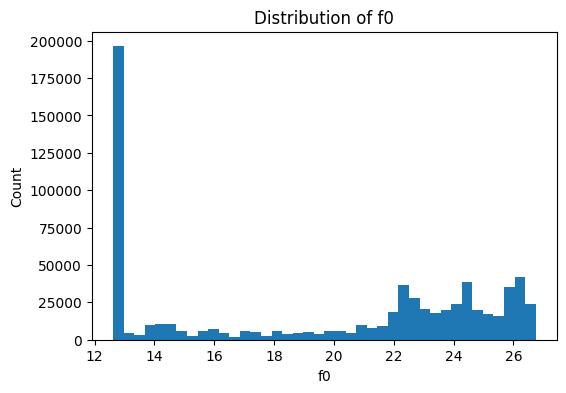

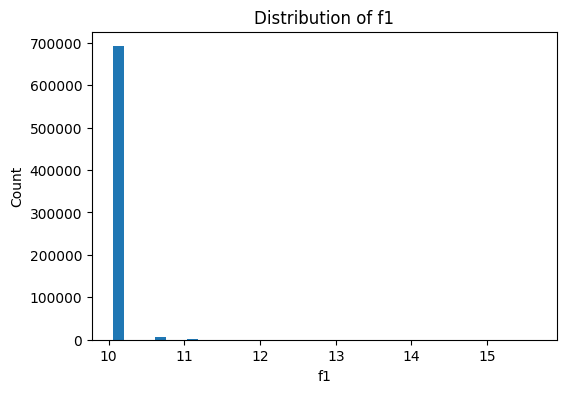

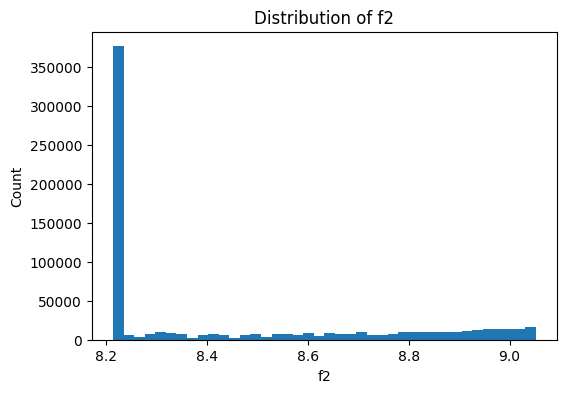

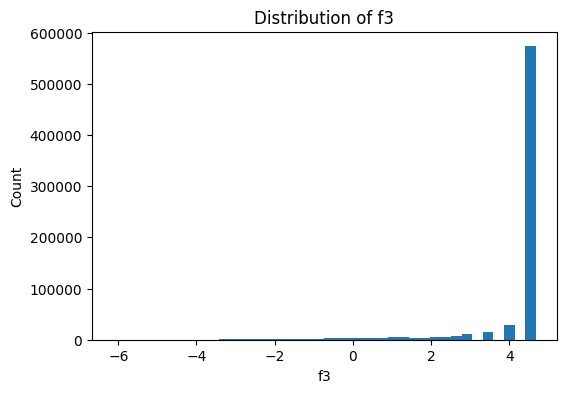

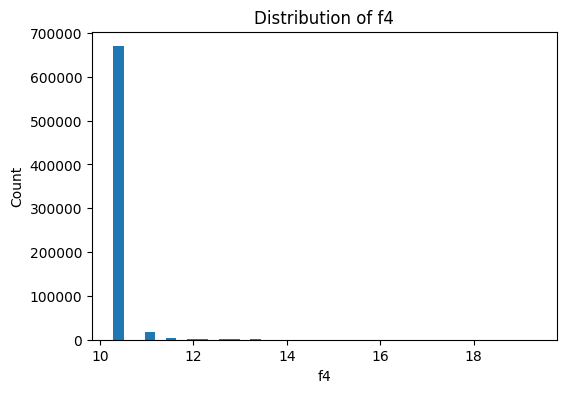

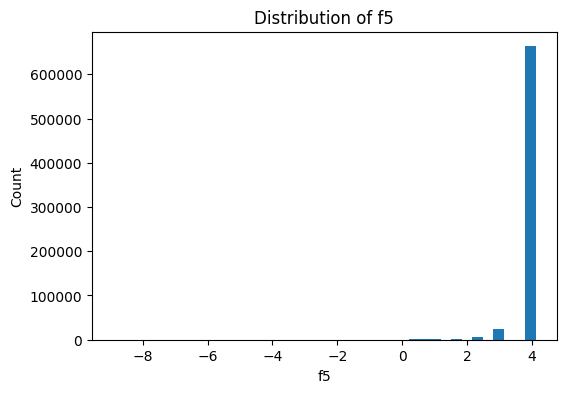

In [9]:
plot_feature_histograms(train_df, max_features=6)

## Train baseline response models

This calls the reusable production training function from:

```text
src/models/train_response_model.py
```

The notebook does not duplicate training logic.


In [10]:
result = train_response_models(experiment_name="response_model_notebook")
result

FileNotFoundError: Training data not found at data\processed\train.parquet. Run the Phase 1 data pipeline first.

## Outputs

The best response model is saved under:

```text
artifacts/response_model.pkl
```

MLflow logs are available in the experiment:

```text
response_model_notebook
```
